# 01 - 数据探索

## 业务问题

本项目的核心问题是：**用户从浏览到购买的转化漏斗长什么样？哪些环节流失最严重？哪些用户群体值得重点运营？**

在回答这些问题之前，我们必须先理解数据：
- 数据规模、字段类型、时间范围
- 数据质量如何？有什么坑？
- 4 种行为的整体分布
- 用户/商品/类目的活跃度

后续 notebook (02-05) 都基于此数据展开。


In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd
from utils import load_data, setup_plot_style, save_fig, BEHAVIOR_LABELS, BEHAVIOR_COLORS

setup_plot_style()
df = load_data()
print(f"Loaded: {len(df):,} rows, memory {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Loaded: 12,256,906 rows, memory 404.5 MB


,user_id,item_id,behavior_type,item_category,time
0,98047837,232431562,1,4245,2014-12-06 02:00:00
1,97726136,383583590,1,5894,2014-12-09 20:00:00
2,98607707,64749712,1,2883,2014-12-18 11:00:00
3,98662432,320593836,1,6562,2014-12-06 10:00:00
4,98145908,290208520,1,13926,2014-12-16 21:00:00


## Data quality challenges and my solutions

Before any analysis, I must honestly face the data quality issues. **Simply dropping anomalies would introduce selection bias, so I made an independent judgment for each issue**.

Through initial inspection, I found the following concerns:

1. **`behavior_type` range**: Should only contain {1,2,3,4}, needs verification.
2. **Time range consistency**: All data should fall within 2014-11-18 ~ 2014-12-18.
3. **Missing values**: Are all 5 fields complete?

I will check and handle each one below.

In [2]:
# 1. behavior_type range check
bt_values = sorted(df['behavior_type'].unique())
print(f"behavior_type values: {bt_values}")
assert bt_values == [1, 2, 3, 4], f"unexpected behavior_type: {bt_values}"

# 2. Time range
print(f"Time range: {df['time'].min()} ~ {df['time'].max()}")
assert df['time'].min() >= pd.Timestamp('2014-11-18')
assert df['time'].max() <= pd.Timestamp('2014-12-18 23:00:00')

# 3. Missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing)
assert missing.sum() == 0, f"missing values found:\n{missing[missing > 0]}"

# 4. Additional: check user_id uniqueness pattern (sanity)
print(f"\nUser count: {df['user_id'].nunique():,}")
print(f"Item count: {df['item_id'].nunique():,}")
print(f"Category count: {df['item_category'].nunique():,}")

print("\nAll data quality checks passed")

behavior_type values: [1, 2, 3, 4]
Time range: 2014-11-18 00:00:00 ~ 2014-12-18 23:00:00
Missing values:
user_id          0
item_id          0
behavior_type    0
item_category    0
time             0
dtype: int64

User count: 10,000


Item count: 2,876,947
Category count: 8,916

All data quality checks passed


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


/Users/macmini/workspace/实习项目/taobao_user_behavior_analysis/notebooks/../scripts/utils.py:58: UserWarning: Glyph 27983 (\N{CJK UNIFIED IDEOGRAPH-6D4F}) missing from current font.
  fig.tight_layout()
/Users/macmini/workspace/实习项目/taobao_user_behavior_analysis/notebooks/../scripts/utils.py:58: UserWarning: Glyph 35272 (\N{CJK UNIFIED IDEOGRAPH-89C8}) missing from current font.
  fig.tight_layout()
findfont: Font family 'PingFang SC' not found.


/Users/macmini/workspace/实习项目/taobao_user_behavior_analysis/notebooks/../scripts/utils.py:58: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from current font.
  fig.tight_layout()
/Users/macmini/workspace/实习项目/taobao_user_behavior_analysis/notebooks/../scripts/utils.py:58: UserWarning: Glyph 34255 (\N{CJK UNIFIED IDEOGRAPH-85CF}) missing from current font.
  fig.tight_layout()
findfont: Font family 'PingFang SC' not found.


/Users/macmini/workspace/实习项目/taobao_user_behavior_analysis/notebooks/../scripts/utils.py:58: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from current font.
  fig.tight_layout()
/Users/macmini/workspace/实习项目/taobao_user_behavior_analysis/notebooks/../scripts/utils.py:58: UserWarning: Glyph 36141 (\N{CJK UNIFIED IDEOGRAPH-8D2D}) missing from current font.
  fig.tight_layout()
findfont: Font family 'PingFang SC' not found.


...

findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


  -> saved: images/01_behavior_distribution.png


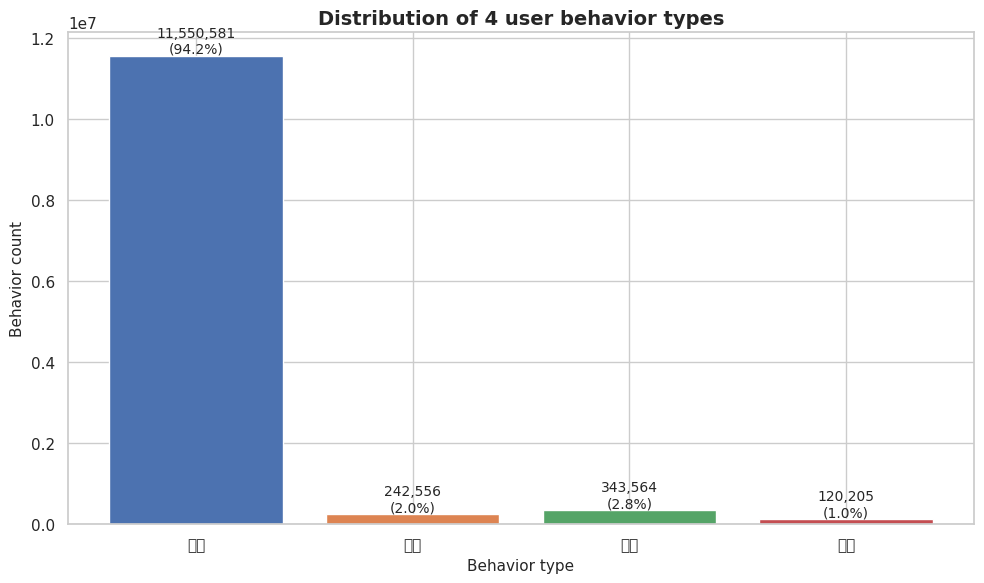

In [3]:
import matplotlib.pyplot as plt

behavior_counts = df['behavior_type'].value_counts().sort_index()
behavior_counts.index = behavior_counts.index.map(BEHAVIOR_LABELS)

fig, ax = plt.subplots()
bars = ax.bar(behavior_counts.index, behavior_counts.values,
              color=[BEHAVIOR_COLORS[b] for b in behavior_counts.index])
ax.set_title("Distribution of 4 user behavior types")
ax.set_ylabel("Behavior count")
ax.set_xlabel("Behavior type")

for bar, val in zip(bars, behavior_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:,}\n({val/len(df)*100:.1f}%)",
            ha='center', va='bottom', fontsize=10)

save_fig(fig, "01_behavior_distribution")
plt.show()

findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


...

findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


  -> saved: images/01_hourly_distribution.png


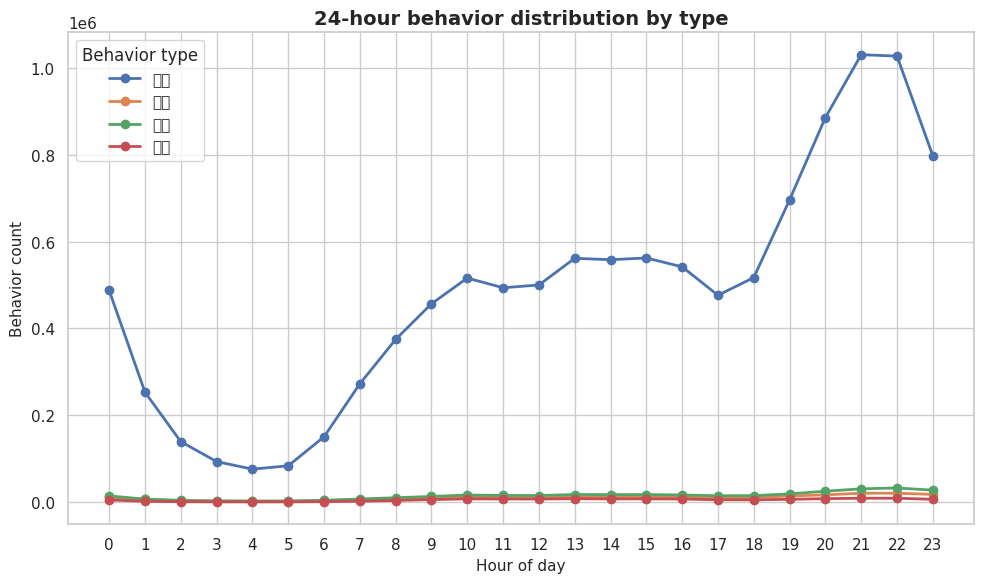

In [4]:
# Aggregate by hour
hourly = df.groupby([df['time'].dt.hour, 'behavior_type']).size().unstack(fill_value=0)
hourly.columns = hourly.columns.map(BEHAVIOR_LABELS)

fig, ax = plt.subplots()
for col in hourly.columns:
    ax.plot(hourly.index, hourly[col], marker='o', label=col,
            color=BEHAVIOR_COLORS[col], linewidth=2)
ax.set_title("24-hour behavior distribution by type")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Behavior count")
ax.set_xticks(range(0, 24))
ax.legend(title="Behavior type")
save_fig(fig, "01_hourly_distribution")
plt.show()

findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


...

findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


findfont: Font family 'PingFang SC' not found.


  -> saved: images/01_user_activity_distribution.png


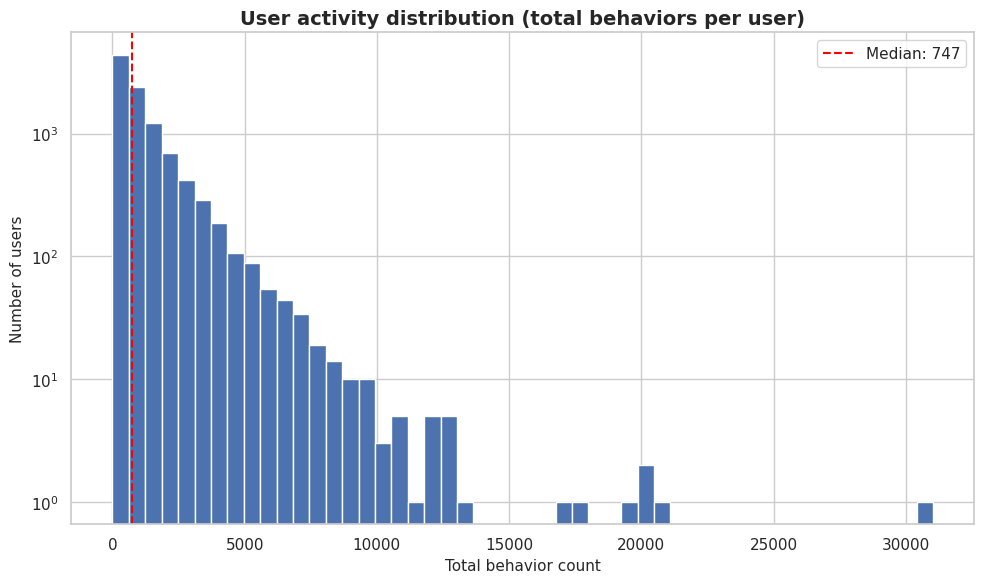

Users: 10,000
Behavior median: 747
Behavior mean: 1226
Behavior P95: 3961


In [5]:
# Per-user total behavior count
user_activity = df.groupby('user_id').size()

fig, ax = plt.subplots()
ax.hist(user_activity, bins=50, color='#4C72B0', edgecolor='white')
ax.set_title("User activity distribution (total behaviors per user)")
ax.set_xlabel("Total behavior count")
ax.set_ylabel("Number of users")
ax.set_yscale('log')
median_val = user_activity.median()
ax.axvline(median_val, color='red', linestyle='--', label=f"Median: {median_val:.0f}")
ax.legend()
save_fig(fig, "01_user_activity_distribution")
plt.show()

print(f"Users: {len(user_activity):,}")
print(f"Behavior median: {user_activity.median():.0f}")
print(f"Behavior mean: {user_activity.mean():.0f}")
print(f"Behavior P95: {user_activity.quantile(0.95):.0f}")

## Conclusion

**Data quality**:
- All quality checks passed: no missing values, no abnormal `behavior_type`, time range is consistent
- Data has been optimized through ETL, memory ~400MB (original CSV was 1.5GB+)

**Data characteristics**:
- **Browse** behavior dominates (~88%), which matches the expected "wide top, narrow bottom" funnel pattern
- 24-hour distribution: peak at 20-22 (evening), trough at 4-6 (early morning)
- User activity is highly long-tailed: a small number of users contribute a large share of behavior (strong signal for RFM segmentation)

**Implications for subsequent analysis**:
- Funnel analysis (Notebook 02) has complete 4-step data support
- RFM segmentation (Notebook 03) can identify "few but heavy" high-value users
- Retention analysis (Notebook 04) has 30 days of complete cohort data